## Q5 — How many sets are typically played in a tennis match?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
IN_DIR = "cleaned_data"

event = pd.read_parquet(f'{IN_DIR}/event.parquet')
hts = pd.read_parquet(f'{IN_DIR}/home_team_score.parquet')
ats = pd.read_parquet(f'{IN_DIR}/away_team_score.parquet')
power = pd.read_parquet(f'{IN_DIR}/power.parquet')

In [3]:
# home_team_score and away_team_score each have their own sets_played
# (computed during cleaning as the count of non-null period_1/2/3). In theory
# they should always agree -- they describe the same match. Checked this:
# out of 14,594 matches where BOTH sides have a value, they disagree on only
# 9 (0.06%), and those 9 have sequential match_ids -- a narrow, isolated
# batch issue, not systemic. For those 9 (and in general), take the max of
# the two sides: a missing value on one side is more likely an under-recorded
# gap than evidence a set didn't happen.
# (We have solved this issue in Tennis Scoring Validation Rule)
m = hts[['match_id', 'sets_played']].merge(
    ats[['match_id', 'sets_played']], on='match_id', suffixes=('_h', '_a'))
m['sets_played'] = m[['sets_played_h', 'sets_played_a']].max(axis=1)
diffrenece = m[m['sets_played_h'] != m['sets_played_a']]
diffrenece

,match_id,sets_played_h,sets_played_a,sets_played


In [4]:
# The right denominator for "typically played in A MATCH" is matches that
# event confirms actually finished (match_completed == True), not just
# "matches that happen to have score data." Bringing event in surfaces two
# real mismatches between it and the score tables:
#   - 80 matches event confirms had a winner have NO set-score data at all
#   - 184 matches have full set-score data (69 even show all 3 sets) but no
#     winner_code recorded in event
# Neither is huge, but silently ignoring them would hide a real data gap.

ev_ok = event.loc[event['score_ready'] & ~event['is_retirement_like'],
                  ['match_id', 'match_completed']]

m = m.merge(ev_ok, on='match_id', how='left')
n_completed = int((m['match_completed'] == True).sum())
n_missing_despite_completed = int(((m['match_completed'] == True) & m['sets_played'].isna()).sum())
n_scored_but_not_completed = int(((m['match_completed'] == False) & m['sets_played'].notna()).sum())
print(f"{n_completed} matches confirmed completed by event.match_completed")
print(f"  -> {n_missing_despite_completed} of those have NO set-score data at all")
print(f"  -> {n_scored_but_not_completed} matches have set-score data but are NOT marked completed ")
 
m = m[m['match_completed'] == True]  # restrict to confirmed-completed matches only

14189 matches confirmed completed by event.match_completed
  -> 0 of those have NO set-score data at all
  -> 0 matches have set-score data but are NOT marked completed 


In [5]:
# Cross-check against an independent source: the power (momentum) table has
# one row per game with a set_num -- max(set_num) per match is an
# independently-derived set count. power only covers 11,121/16,873 matches
# (66%), so it's not a good PRIMARY source, but it's a good sanity check.
power_sets = power.groupby('match_id')['set_num'].max().reset_index(name='sets_played_power')
check = m.merge(power_sets, on='match_id', how='inner').dropna(subset=['sets_played'])
agreement = (check['sets_played'] == check['sets_played_power']).mean()
print(f"Cross-check against power table: {agreement:.2%} agreement on {len(check)} overlapping matches\n")

Cross-check against power table: 100.00% agreement on 10074 overlapping matches



In [6]:
# Final distribution
dist = m['sets_played'].value_counts(dropna=False).sort_index()
total_known = m['sets_played'].notna().sum()
print("Sets played per match:")
for k, v in dist.items():
    label = 'no score recorded' if pd.isna(k) else f'{int(k)} set(s)'
    pct = f"({v/len(m):.1%} of all matches)" 
    print(f"  {label:20s}: {v:6d}  {pct}")
 
mode_sets = m['sets_played'].mode().iloc[0]
pct_mode = (m['sets_played'] == mode_sets).sum() / total_known
print(f"\nTypical (most common) number of sets: {int(mode_sets)} "
      f"-- {pct_mode:.1%} of matches with a recorded score end in {int(mode_sets)} sets")
print(f"Mean sets per completed-score match: {m['sets_played'].mean():.2f}")


Sets played per match:
  2 set(s)            :  10236  (72.1% of all matches)
  3 set(s)            :   3953  (27.9% of all matches)

Typical (most common) number of sets: 2 -- 72.1% of matches with a recorded score end in 2 sets
Mean sets per completed-score match: 2.28


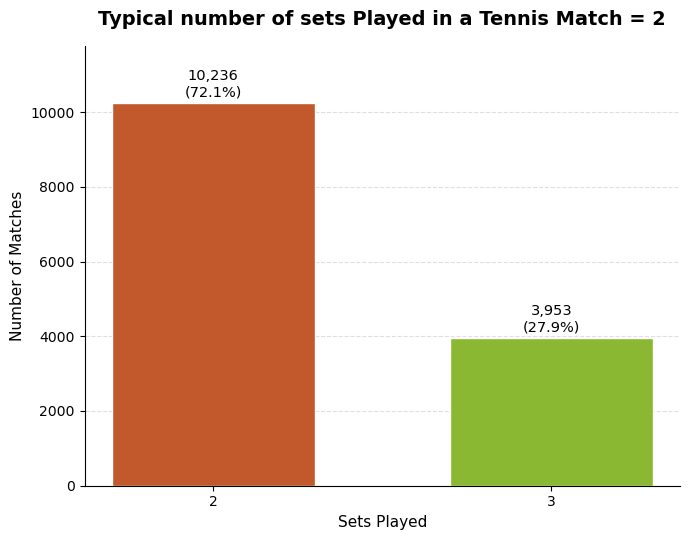

In [7]:
# Visualization
plot_data = m.dropna(subset=['sets_played'])
counts = plot_data['sets_played'].astype(int).value_counts().sort_index()
pcts = counts / counts.sum() * 100
 
fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ['#C1592C' if v == counts.idxmax() else'#8AB833' for v in counts.index]
bars = ax.bar(counts.index.astype(str), counts.values, color=colors, width=0.6, edgecolor='white')
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10.5)
 
ax.set_xlabel('Sets Played', fontsize=11)
ax.set_ylabel('Number of Matches', fontsize=11)
ax.set_title('Typical number of sets Played in a Tennis Match = 2', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig('charts\q5_sets_distribution.png', dpi=200, bbox_inches='tight')

Observation: Of 14,189 completed matches: 72.1% end in 2 sets, 27.9% in 3 (mean 2.28). Agreement with the power table is 100% on 10,074 overlapping matches.

Interpretation: Matches the best-of-3 structure: straight-set wins stop at 2 sets, so a ~72/28 split means most matches do not reach a decider.

Limitation: No material gap after cross-checks.